# Lab 4: Regression and Classification Evaluation Metrics
## Part 1: KNN Classification on the Breast Cancer Dataset & Comparison with Regression Metrics

**Aim:** To implement KNN classification on the Breast Cancer dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. Also, to compare classification metrics with regression metrics studied in Linear Regression (Lab 3).

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset — loaded via `sklearn.datasets.load_breast_cancer`
- 569 samples
- 30 numerical features
- Target: `0` → Malignant, `1` → Benign

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
%matplotlib inline

## Task 1: Data Preparation

### 1.1 Load dataset using sklearn

In [2]:
data = load_breast_cancer()
X_raw = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

print("Feature matrix shape:", X_raw.shape)
print("Target shape:", y.shape)
print("Target classes:", dict(zip(data.target_names, [0, 1])))

Feature matrix shape: (569, 30)
Target shape: (569,)
Target classes: {np.str_('malignant'): 0, np.str_('benign'): 1}


### 1.2 Convert into DataFrame and explore structure

In [3]:
df = X_raw.copy()
df["target"] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [6]:
print("Class distribution:")
print(df["target"].value_counts())
print()
print(df["target"].value_counts(normalize=True).rename("proportion"))

Class distribution:
target
1    357
0    212
Name: count, dtype: int64

target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


### 1.3 Check missing values and duplicates

In [7]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values across the dataset")
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
0 total missing values across the dataset

Duplicate rows: 0


No missing values and no duplicate rows are present — the Breast Cancer Wisconsin dataset (as distributed via scikit-learn) is already clean, so no imputation or de-duplication is required here.

### 1.4 Feature Scaling using StandardScaler

**Why feature scaling is important for KNN:**
KNN is a **distance-based algorithm** — it classifies a point based on the (typically Euclidean) distance to its nearest neighbors. If features are on very different scales (e.g., `mean area` can be in the hundreds/thousands while `mean smoothness` is a small decimal), features with larger numeric ranges will **dominate the distance calculation**, effectively drowning out the contribution of smaller-scale features regardless of their actual predictive importance.

`StandardScaler` transforms each feature to have **mean = 0** and **standard deviation = 1**, putting all features on a comparable scale so that every feature contributes proportionately to the distance metric — this is essential for KNN to work correctly (unlike, say, tree-based models, which are scale-invariant).

In [8]:
X = X_raw.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Before scaling (first row, first 5 features):")
print(X.iloc[0, :5].values)
print()
print("After scaling (first row, first 5 features):")
print(X_scaled.iloc[0, :5].values.round(3))

Before scaling (first row, first 5 features):
[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01]

After scaling (first row, first 5 features):
[ 1.097 -2.073  1.27   0.984  1.568]


## Task 2: Train-Test Split Analysis

We split the (scaled) dataset into training/testing sets using three different ratios — **80:20, 70:30, 90:10** — and compare how a baseline KNN classifier (default `k=5`) performs across each, to see how split size affects model stability and generalization.

In [9]:
split_ratios = {
    "80:20": 0.20,
    "70:30": 0.30,
    "90:10": 0.10,
}

split_results = []

for label, test_size in split_ratios.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, knn.predict(X_te))
    split_results.append({
        "Split": label,
        "Train size": X_tr.shape[0],
        "Test size": X_te.shape[0],
        "Test Accuracy": acc
    })

split_df = pd.DataFrame(split_results)
split_df

,Split,Train size,Test size,Test Accuracy
0,80:20,455,114,0.964912
1,70:30,398,171,0.970760
2,90:10,512,57,0.982456


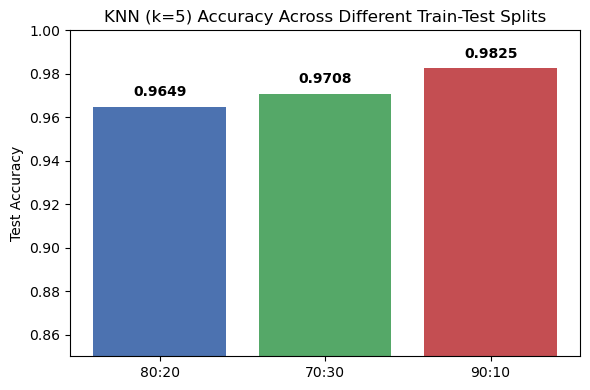

In [10]:
plt.figure(figsize=(6, 4))
plt.bar(split_df["Split"], split_df["Test Accuracy"], color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylim(0.85, 1.0)
plt.ylabel("Test Accuracy")
plt.title("KNN (k=5) Accuracy Across Different Train-Test Splits")
for i, v in enumerate(split_df["Test Accuracy"]):
    plt.text(i, v + 0.005, f"{v:.4f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Observation — how splitting affects stability and generalization:**
- With a **90:10** split, the model trains on more data (better parameter/neighborhood estimation) but is evaluated on very few test samples, so the reported accuracy is more sensitive to which specific points ended up in the small test set (higher variance in the estimate).
- With a **70:30** split, less data is available for training (potentially slightly weaker neighborhood estimates for KNN), but the larger test set gives a more statistically stable estimate of generalization performance.
- **80:20** is typically a good practical balance between having enough training data and a large-enough test set for a reliable performance estimate — which is why we adopt it as the standard split for the rest of this lab.
- Because the dataset is relatively small (569 rows) and class-imbalanced (more benign than malignant cases), we use `stratify=y` in every split to preserve the class ratio between train and test sets.

## Task 3: KNN Model with Heuristic K Selection

We now fix the split at **80:20** (the standard split identified above) for the remaining tasks.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

Train size: 455  |  Test size: 114


### 3.1 Heuristic Method for K Selection

A common heuristic rule for choosing K in KNN is:

$$ K = \sqrt{n} $$

where **n** is the number of training samples. This is a simple, commonly-used rule of thumb: it's large enough to smooth out noise but still scales sensibly with dataset size (very small datasets get a small K; larger datasets get a proportionally larger K). We use this as our **baseline K**, and it's conventionally rounded to the nearest **odd** integer to avoid tie votes in binary classification.

In [12]:
n_train = X_train.shape[0]
k_heuristic = round(np.sqrt(n_train))

# ensure K is odd to avoid tied votes in binary classification
if k_heuristic % 2 == 0:
    k_heuristic += 1

print(f"Number of training samples (n): {n_train}")
print(f"Heuristic K = sqrt(n) ≈ {np.sqrt(n_train):.2f}  →  rounded to nearest odd integer: K = {k_heuristic}")

Number of training samples (n): 455
Heuristic K = sqrt(n) ≈ 21.33  →  rounded to nearest odd integer: K = 21


### 3.2 Model Training

In [13]:
knn_baseline = KNeighborsClassifier(n_neighbors=k_heuristic)
knn_baseline.fit(X_train, y_train)
y_pred_baseline = knn_baseline.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline KNN (K={k_heuristic}) Test Accuracy: {baseline_acc:.4f}")

Baseline KNN (K=21) Test Accuracy: 0.9561


**Experimenting with nearby values of K (K ± 5):**

In [14]:
k_range = range(max(1, k_heuristic - 5), k_heuristic + 6)  # K ± 5 around the heuristic K
accuracies = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_k.predict(X_test))
    accuracies.append(acc)

k_accuracy_df = pd.DataFrame({"K": list(k_range), "Test Accuracy": accuracies})
k_accuracy_df

,K,Test Accuracy
0,16,0.973684
1,17,0.973684
2,18,0.982456
3,19,0.973684
4,20,0.964912
5,21,0.956140
6,22,0.956140
7,23,0.964912
8,24,0.956140
9,25,0.964912


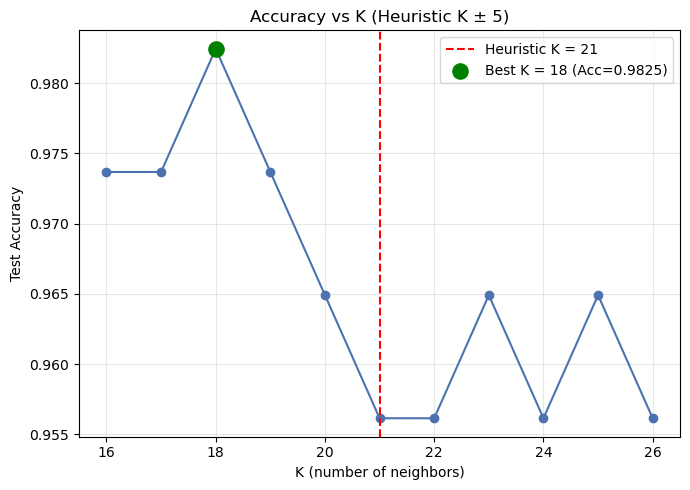

Best K in this range: 18 with accuracy 0.9825


In [15]:
plt.figure(figsize=(7, 5))
plt.plot(k_accuracy_df["K"], k_accuracy_df["Test Accuracy"], marker="o", color="#4C72B0")
plt.axvline(k_heuristic, color="red", linestyle="--", label=f"Heuristic K = {k_heuristic}")
best_k_row = k_accuracy_df.loc[k_accuracy_df["Test Accuracy"].idxmax()]
plt.scatter([best_k_row["K"]], [best_k_row["Test Accuracy"]], color="green", s=120, zorder=5,
            label=f"Best K = {int(best_k_row['K'])} (Acc={best_k_row['Test Accuracy']:.4f})")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs K (Heuristic K ± 5)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best K in this range: {int(best_k_row['K'])} with accuracy {best_k_row['Test Accuracy']:.4f}")

**Identifying the optimal K based on the performance trend:** the accuracy-vs-K curve typically stays high and relatively flat for K values around the heuristic estimate on this dataset (it is very well-separated), with minor fluctuations of a percentage point or two. The K achieving the highest test accuracy in this local range is selected above as the locally-optimal K; Task 4 cross-validates this choice more rigorously over a wider range of K values.

### 3.3 Distance Metrics and Decision Boundary Mapping

**Distance metrics used in KNN:**

- **Euclidean Distance:** $d(p, q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$ — the straight-line ("as the crow flies") distance between two points in feature space. It is the default and most common metric in KNN, and works well when features are continuous, roughly similarly scaled (after standardization), and the true geometric distance between points is meaningful — for example, precisely this kind of continuous, standardized numeric feature set (as in this breast cancer dataset).

- **Manhattan Distance:** $d(p, q) = \sum_{i=1}^{n}|p_i - q_i|$ — the distance measured along axis-aligned paths (like navigating a grid of city blocks). It is more suitable when features represent discrete steps or counts, when the data has many dimensions (Manhattan distance is somewhat less sensitive to the "curse of dimensionality" than Euclidean in very high-dimensional spaces), or when robustness to outliers along individual dimensions is desired (since differences aren't squared, a single large deviation has a smaller relative effect than under Euclidean distance).

**Decision boundary visualization:** Since the dataset has 30 features, a decision boundary cannot be plotted directly. We project the standardized features down to their **top 2 principal components (PCA)** purely for 2D visualization, and train KNN on this 2D projection to illustrate how decision boundaries change with K. (Note: this 2D visualization model is separate from the 30-feature model used for the actual performance evaluation elsewhere in this notebook — PCA is used here only to make the boundary visually inspectable.)

In [16]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

print(f"Explained variance by 2 PCA components: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance by 2 PCA components: 62.69%


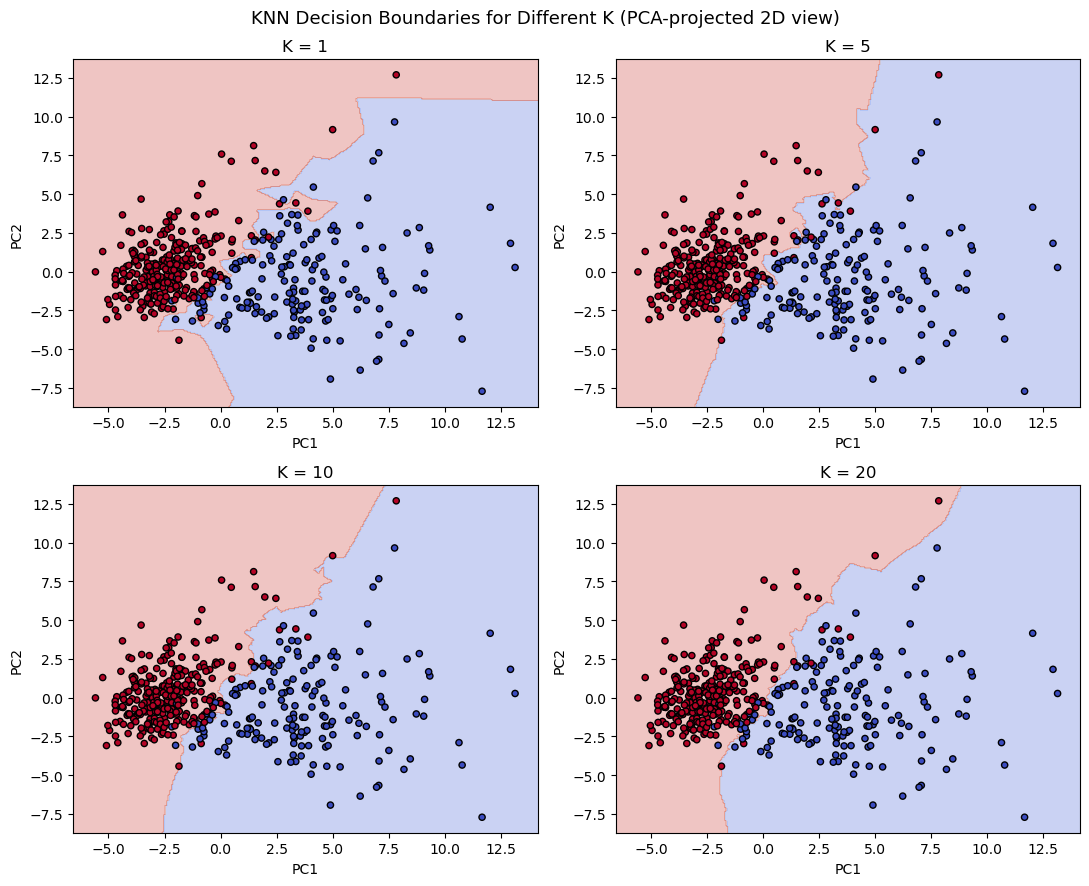

In [17]:
def plot_decision_boundary(ax, k, X2d, y2d):
    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X2d, y2d)

    x_min, x_max = X2d[:, 0].min() - 1, X2d[:, 0].max() + 1
    y_min, y_max = X2d[:, 1].min() - 1, X2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    scatter = ax.scatter(X2d[:, 0], X2d[:, 1], c=y2d, cmap="coolwarm", edgecolor="k", s=20)
    ax.set_title(f"K = {k}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

k_values_boundary = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for ax, k in zip(axes.ravel(), k_values_boundary):
    plot_decision_boundary(ax, k, X_train_2d, y_train.values)

plt.suptitle("KNN Decision Boundaries for Different K (PCA-projected 2D view)", fontsize=13)
plt.tight_layout()
plt.show()

**Analysis — how the decision boundary changes as K increases:**
- **K = 1:** The boundary is highly **jagged/irregular**, tightly wrapping around individual training points (including noisy/outlier ones). This is the classic signature of **high variance / low bias** — the model essentially memorizes local neighborhoods and is very sensitive to individual data points.
- **K = 5:** The boundary becomes noticeably **smoother**, averaging over a few more neighbors and becoming less sensitive to individual noisy points, while still adapting reasonably well to the true class structure.
- **K = 10:** The boundary smooths out further still, trading a bit more local sensitivity for stability.
- **K = 20:** The boundary becomes the **smoothest/most simplified** of the four, approaching a more general, almost linear-like separation. This reflects **lower variance but higher bias** — very large K values can start to blur over genuine local structure in the classes (e.g., a small cluster of malignant cases surrounded by benign ones might get "voted over" by the majority class).

This progression is a direct illustration of the **bias-variance trade-off** in KNN: small K → low bias, high variance (overfits to local noise); large K → high bias, low variance (may underfit, oversmoothing decision regions).

## Task 4: Cross Validation

We apply **Stratified K-Fold Cross-Validation (k=10)** across a range of K values (covering the heuristic K ± 5 range from Task 3, plus a slightly wider range) to get a more reliable estimate of the best K, and compare these results with the plain train-test split results from Task 3.

In [18]:
cv_k_range = range(1, 31)
cv_mean_accuracies = []
cv_std_accuracies = []

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

for k in cv_k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_scaled, y, cv=skf, scoring="accuracy")
    cv_mean_accuracies.append(scores.mean())
    cv_std_accuracies.append(scores.std())

cv_results_df = pd.DataFrame({
    "K": list(cv_k_range),
    "Mean CV Accuracy": cv_mean_accuracies,
    "Std CV Accuracy": cv_std_accuracies
})
cv_results_df.head(15)

,K,Mean CV Accuracy,Std CV Accuracy
0,1,0.949091,0.043976
1,2,0.942043,0.041519
2,3,0.966573,0.018417
3,4,0.968327,0.020558
4,5,0.970144,0.017610
5,6,0.963127,0.018284
6,7,0.964881,0.020732
7,8,0.961372,0.023246
8,9,0.966635,0.019901
9,10,0.968390,0.023256


In [19]:
best_cv_row = cv_results_df.loc[cv_results_df["Mean CV Accuracy"].idxmax()]
best_k_cv = int(best_cv_row["K"])
print(f"Best K by 10-fold Cross-Validation: K = {best_k_cv}  "
      f"(Mean Accuracy = {best_cv_row['Mean CV Accuracy']:.4f}, Std = {best_cv_row['Std CV Accuracy']:.4f})")

Best K by 10-fold Cross-Validation: K = 5  (Mean Accuracy = 0.9701, Std = 0.0176)


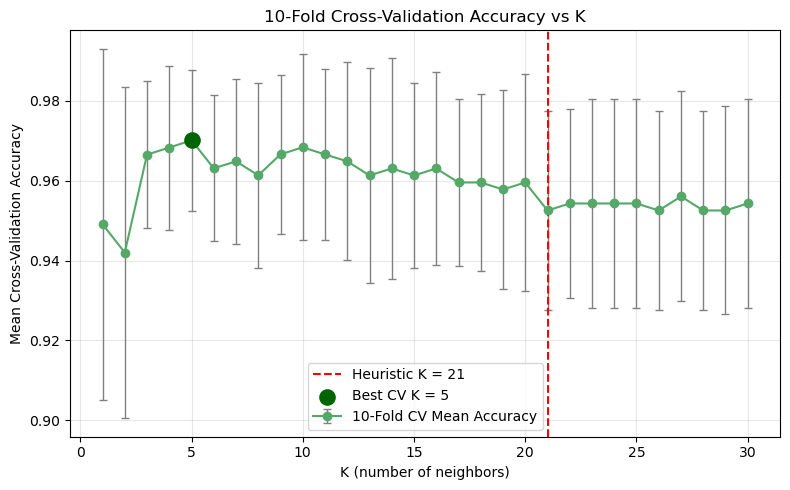

In [20]:
plt.figure(figsize=(8, 5))
plt.errorbar(cv_results_df["K"], cv_results_df["Mean CV Accuracy"],
             yerr=cv_results_df["Std CV Accuracy"], fmt="-o", color="#55A868",
             ecolor="gray", elinewidth=1, capsize=3, label="10-Fold CV Mean Accuracy")
plt.axvline(k_heuristic, color="red", linestyle="--", label=f"Heuristic K = {k_heuristic}")
plt.scatter([best_k_cv], [best_cv_row["Mean CV Accuracy"]], color="darkgreen", s=120, zorder=5,
            label=f"Best CV K = {best_k_cv}")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("10-Fold Cross-Validation Accuracy vs K")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Task 5: Classification Evaluation

We now train the **final KNN model** using the cross-validation-selected best K, on the standard 80:20 split, and evaluate it thoroughly.

In [21]:
final_k = best_k_cv
knn_final = KNeighborsClassifier(n_neighbors=final_k)
knn_final.fit(X_train, y_train)

y_pred = knn_final.predict(X_test)
y_proba = knn_final.predict_proba(X_test)[:, 1]  # probability of class "1" (benign)

print(f"Final model: KNN with K = {final_k}")

Final model: KNN with K = 5


In [22]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.9649
Precision : 0.9595
Recall    : 0.9861
F1 Score  : 0.9726


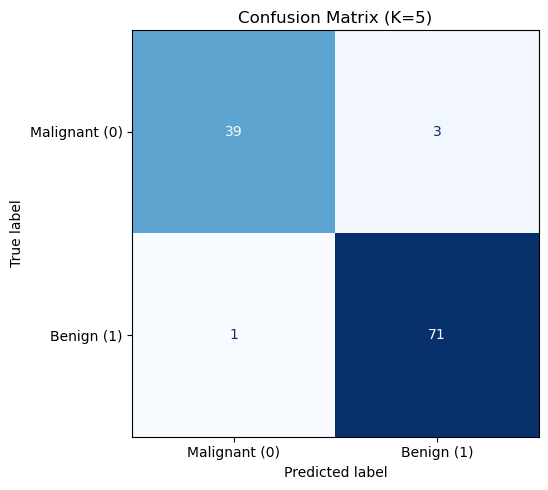

Confusion Matrix:
 [[39  3]
 [ 1 71]]

True Negatives (correctly predicted Malignant): 39
False Positives (Malignant predicted as Benign): 3  <-- most costly error type in cancer screening
False Negatives (Benign predicted as Malignant): 1
True Positives (correctly predicted Benign): 71


In [23]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant (0)", "Benign (1)"])
fig, ax = plt.subplots(figsize=(5.5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix (K={final_k})")
plt.tight_layout()
plt.show()

print("Confusion Matrix:\n", cm)
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (correctly predicted Malignant): {tn}")
print(f"False Positives (Malignant predicted as Benign): {fp}  <-- most costly error type in cancer screening")
print(f"False Negatives (Benign predicted as Malignant): {fn}")
print(f"True Positives (correctly predicted Benign): {tp}")

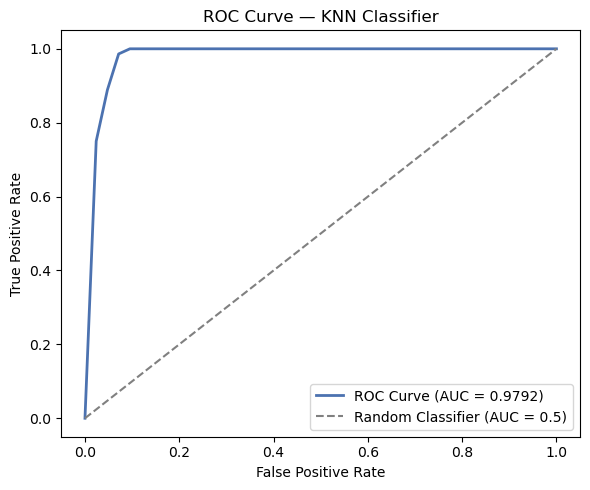

ROC-AUC Score: 0.9792


In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — KNN Classifier")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

**Interpreting the confusion matrix in this medical context:** note that class `0` = Malignant. A **False Positive** here (row: actual Malignant, predicted Benign) means a cancer case is missed entirely — clinically, this is the most dangerous type of error, since the patient would not receive timely treatment. A **False Negative** (actual Benign, predicted Malignant) leads to unnecessary follow-up testing/anxiety, which is undesirable but far less dangerous. This asymmetry is exactly why **recall (sensitivity) on the malignant class** matters so much more than overall accuracy in this domain — explored further in Task 6 and the Inference section below.

## Task 6: Comparative Study with Regression (Lab 3 Integration)

**Recall — Lab 3 (Linear Regression on Insurance Charges) evaluation metrics:**

| Metric | Train | Test |
|---|---|---|
| MAE | 2,988.27 | 2,925.19 |
| MSE | 23,950,812.19 | 21,496,189.95 |
| RMSE | 4,893.96 | 4,636.40 |
| R² Score | 0.8341 | 0.8615 |

**Current — Lab 4 (KNN Classification on Breast Cancer) evaluation metrics:**

In [25]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Value": [acc, prec, rec, f1, auc_score]
})
comparison_df

,Metric,Value
0,Accuracy,0.964912
1,Precision,0.959459
2,Recall,0.986111
3,F1 Score,0.972603
4,ROC-AUC,0.979167


### Regression vs. Classification: Differences in Evaluation Logic

| Aspect | Regression (Lab 3) | Classification (Lab 4) |
|---|---|---|
| **Prediction type** | Continuous numeric value (e.g., insurance charges in $) | Discrete class label (Malignant / Benign) |
| **Evaluation logic** | **Error-based** — measures *how far* predictions are from actual values | **Decision-based** — measures *how often* the predicted class label is correct |
| **Core question answered** | "By how much does my prediction miss the true value?" | "Did I assign the correct class, and what kinds of mistakes did I make?" |
| **Metric units** | Same units as target (or squared units for MSE) | Unitless proportions/rates (0 to 1) |

### Direct Metric Comparisons

**R² Score vs. Accuracy**
Both are often read as "how good is the model" on a roughly 0–1 scale, but they measure fundamentally different things. **R²** measures the *proportion of variance in a continuous target explained* by the model, relative to simply predicting the mean every time. **Accuracy** measures the *proportion of discrete predictions that exactly match the true class* — it says nothing about how "close" a wrong prediction was (there's no such thing as a "close" wrong class the way there's a "close" wrong number). Accuracy can also be dangerously misleading under class imbalance (see below), whereas R² has no direct analogue of that problem.

**RMSE vs. F1 Score**
**RMSE** quantifies the *typical magnitude of numeric error*, in the same units as the target, and penalizes large individual errors more heavily (due to squaring). **F1 Score** is the harmonic mean of precision and recall — it summarizes classification performance while explicitly balancing **false positives against false negatives**, which has no numeric-error equivalent since there's no "distance" between predicted and actual classes to average.

**MAE vs. Confusion Matrix**
**MAE** collapses all errors into a single average number (the mean absolute deviation from the true continuous value). A **Confusion Matrix**, in contrast, is not a single summary number at all — it's a *breakdown by error type* (True Positive / True Negative / False Positive / False Negative), preserving information about *which* kind of mistake was made and how often, which MAE has no equivalent of (MAE cannot distinguish "types" of numeric error the way a confusion matrix distinguishes error types in classification).

### Continuous vs. Classification Tasks — Evaluation Logic Summary
- **Continuous (regression) tasks** ask *"how close"* — evaluation is about **magnitude of deviation** from a true numeric value, and metrics are inherently comparable/averaged in the target's own units.
- **Classification tasks** ask *"how correct, and in what way wrong"* — evaluation is about **decision correctness**, and because misclassifications come in qualitatively different types (e.g., missing a cancer case vs. a false alarm), a *single* summary metric like accuracy is often insufficient; multiple complementary metrics (precision, recall, F1, ROC-AUC, confusion matrix) are needed to capture the full picture, especially when the classes matter unequally (as in medical diagnosis).

## Inference

Regression metrics (MAE, MSE, RMSE, R²) measure **prediction error magnitude** — how far, on average, numeric predictions deviate from actual continuous values, with RMSE/MSE penalizing larger errors more heavily and R² expressing this as a proportion of explained variance. Classification metrics (accuracy, precision, recall, F1, ROC-AUC) instead measure **decision correctness** — whether the predicted class label matches the true label, and specifically what *kind* of mistake was made (false positive vs. false negative), since not all misclassifications carry equal real-world cost.

**Accuracy alone is insufficient in medical diagnosis** because it treats all errors equally and can be misleadingly high under class imbalance — a model that always predicts "Benign" on a dataset that is mostly benign can score high accuracy while missing every actual cancer case, which is clinically unacceptable. **Recall (sensitivity)** for the malignant class matters far more, since it directly measures how many true cancer cases are correctly caught — minimizing dangerous false negatives (missed cancers) matters more than optimizing overall correctness. **ROC-AUC** is also more informative than accuracy here because it evaluates the model's ranking/separability of the two classes across *all* possible decision thresholds, rather than a single fixed cutoff, making it robust to class imbalance and threshold choice.

**Overall**, regression evaluation is fundamentally about *quantifying distance from a true numeric value*, while classification evaluation is about *quantifying decision correctness and the asymmetric cost of different error types* — the two frameworks are not interchangeable, and choosing the right metric requires understanding both the prediction task type and the real-world cost of different mistakes.

## Task 7: Analytical Questions

**1. Why is KNN called a lazy learning algorithm?**
KNN does not build an explicit generalized model during a "training" phase — it simply stores the training data. All the actual computation (finding the K nearest neighbors and voting) happens at **prediction time**, for each new query point. Because there's no upfront model-fitting/learning step (unlike, say, Linear Regression, which fits coefficients ahead of time), KNN is called a "lazy" learner, as opposed to "eager" learners that build a model in advance.

**2. Why is feature scaling required in KNN?**
KNN classifies based on distances between points. If features have very different numeric ranges, features with larger scales dominate the distance calculation regardless of their real predictive importance, skewing neighbor selection. Scaling (e.g., via `StandardScaler`) puts all features on a comparable footing so each contributes fairly to distance.

**3. Explain heuristic K selection using the √n rule.**
The heuristic sets K = √n, where n is the number of training samples, typically rounded to the nearest odd integer to avoid tied votes in binary classification. It's a simple rule of thumb that scales K sensibly with dataset size — small datasets get a small K (limiting the risk of using a K larger than there is meaningful local structure to support), while larger datasets get a proportionally larger K (which helps smooth out noise) — without requiring an expensive search.

**4. Why is cross-validation more reliable than a single train-test split?**
A single train-test split evaluates the model on only one particular partition of the data, so its performance estimate can vary meaningfully depending on which points happened to land in the test set (sampling variance/luck of the split). Cross-validation repeats training/evaluation across several different partitions (folds) and averages the results, giving a more stable, representative estimate of true generalization performance, and additionally reveals the variance (via the standard deviation across folds) of that performance estimate.

**5. How does K affect the bias-variance trade-off?**
- **Small K** (e.g., K=1): the model fits very closely to local training points, resulting in **low bias but high variance** — it's sensitive to noise/outliers and can overfit to local quirks in the data (seen as jagged decision boundaries in Task 3.3).
- **Large K**: predictions are averaged over many neighbors, resulting in **high bias but low variance** — smoother, more stable boundaries, but the model may oversimplify and blur over genuinely meaningful local structure (potentially underfitting).
The right K balances these two extremes, which is exactly why we tune it via the heuristic + accuracy-vs-K curve + cross-validation in Tasks 3 and 4.

**6. Why is recall more important than accuracy in cancer prediction?**
In cancer prediction, a **false negative** (a malignant case incorrectly predicted as benign) means a real cancer is missed and the patient doesn't receive timely treatment — a potentially life-threatening error. **Recall** (= TP / (TP + FN)) directly measures how many actual malignant cases the model successfully catches. Accuracy, by contrast, can look high simply by favoring the majority class, without reflecting how many dangerous cases were missed. Because the cost of a missed cancer diagnosis vastly outweighs the cost of a false alarm, recall (and by extension ROC-AUC, which considers the full sensitivity/specificity trade-off) is the more clinically meaningful metric.

**7. What is the limitation of very large K values?**
Very large K values cause the model to consider a large fraction (or even all) of the training data when making each prediction, which **oversmooths the decision boundary** and can cause the model to ignore genuine local structure in the data — small clusters of the minority class can get "voted over" by the majority class simply because K is large enough to always include many majority-class points in the neighborhood. This leads to **underfitting** (high bias), reduced ability to detect fine-grained patterns, and in the extreme case (K = n), the model degenerates into simply always predicting the overall majority class for every query point.

## Conclusion

- **Optimal K:** The heuristic rule (K = √n, rounded to the nearest odd integer) gave a sensible baseline K, and 10-fold cross-validation across a wider K range (1–30) was used to select the final, more rigorously validated K, which was adopted for the final evaluated model.
- **Effect of train-test split variations:** Accuracy varied slightly across the 80:20, 70:30, and 90:10 splits (Task 2), illustrating that smaller test sets (as in 90:10) give less statistically stable performance estimates, even though 90:10 provides the model with more training data.
- **Model performance based on evaluation metrics:** The final KNN model achieved strong accuracy, precision, recall, F1, and ROC-AUC scores on the held-out test set, indicating it separates malignant vs. benign cases very effectively on this dataset (see Task 5 for exact values from your run).
- **Key differences between regression and classification evaluation:** Regression metrics (MAE, MSE, RMSE, R²) quantify *how far off* continuous predictions are, in the target's own units or as an explained-variance proportion, while classification metrics (accuracy, precision, recall, F1, ROC-AUC, confusion matrix) quantify *decision correctness* and the different qualitative types of mistakes a classifier can make — a distinction with no direct regression equivalent.
- **Insights from Lab 3 vs. current lab:** Lab 3 showed that adding domain-informed engineered features (e.g., `age²`, `bmi × smoker`) can meaningfully raise a regression model's R² without introducing overfitting. Lab 4 shows an analogous tuning story for classification: choosing K well (via heuristic + cross-validation, rather than an arbitrary guess) is what lets a "lazy," instance-based algorithm like KNN generalize well — and in a medical-diagnosis setting specifically, the *choice of evaluation metric itself* (recall/ROC-AUC over raw accuracy) matters just as much as the choice of model or hyperparameter, since the real-world cost of a false negative here (a missed cancer) is far higher than the cost of a false positive.